# CNN 1D - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele CNN 1D.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente,
- produire une fiche modele avec metriques et sorties graphiques.

In [21]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.extract import add_target, load_features_for_approach
from pipeline.pretraitement import (
    apply_preprocess,
    apply_target_discretization,
    prepare_splits_and_impute,
    display_target_info
)
from pipeline.visu_pretraitement import (
    plot_feature_report,
    plot_preprocessing_report_by_approach,
    plot_split_report,
)
from pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
    train_with_optional_hyperparameter_search
)
from pipeline.reporting import export_visual_report

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

Seed globale: 42


## 1) Profils modulaires

In [34]:
# Ajuster ces profils pour chaque experience
# Template source: pipeline/config.md (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Données brutes/DataPhase1_time.csv",
    "subject_id_col": "Participant",
    "time_col": "Time",
}

PREPROCESS_PROFILE = {
    "approach": "B", # "A" (indicateurs) ou "B" (temporel)
    "use_frequency_resampling": True,
    # Methode de reechantillonnage:
    # - "uniform_time_step": uniformise uniquement le pas temporel (interpolation)
    # - "lomb_scargle": reconstruction harmonique sur frequence(s) cible(s)
    "frequency_resampling_method": "uniform_time_step",
    # Pas temporel cible en secondes. None => mediane des deltas observes.
    "uniform_time_step_s": 1,
    # Utilise uniquement si frequency_resampling_method == "lomb_scargle".
    # "frequency_sampling_hz": [0.1, 0.4],

    # Filtrage passe-bas
    "apply_temporal_lowpass": False,
    "lowpass_cutoff_hz": 0.2,
    "lowpass_order": 4,
    "lowpass_min_points": 16,
    "lowpass_features": "all",  # "all" ou liste explicite de features

    # Filtre passe-haut
    "apply_temporal_highpass": False,
    "highpass_cutoff_hz": 0.08,
    "highpass_order": 8,
    "highpass_min_points": 16,
    "highpass_features": [
        "RotX",
        "RotY",
        "RotZ",
        "X gaze direction",
        "Y gaze direction",
    ],  # "all" ou liste de noms

    # Filtrage passe-bande
    "apply_temporal_bandpass": True,
    "bandpass_ranges_hz": [
        [0.08, 0.12],
        [0.38, 0.42],
    ],
    "bandpass_order": 4,
    "bandpass_min_points": 16,
    "bandpass_features": [
        "RotX",
        "RotY",
        "RotZ",
        "X gaze direction",
        "Y gaze direction",
    ],

    "clip_quantiles": [0.01, 0.99],   # clip sur les features
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": None,  # None / "standard" / "minmax"
    
    "time_col": "time",
    "time_unit": "s",
    "subject_id_col": "subject_id",
    # Colonnes a exclure des features (insensible a la casse)
    "exclude_features": ["minute", "time", "sampling_hz", "row_id", "Left Pupil Diameter", "Right Pupil Diameter"],
    # Colonnes aggrégées
    "column_aggregations": {
        "Pupil diameter AVG": {
            "columns": ["Left Pupil Diameter", "Right Pupil Diameter"],
            "strategy": "mean"
        },
    },
    # include_features : "all" ou liste de colonnes a inclure
    "include_features": [
        "HMDPosX",
        "HMDPosY",
        "HMDPosZ",
        "RotX",
        "RotY",
        "RotZ",
        "Pupil diameter AVG",
        "X gaze direction",
        "Y gaze direction",
        "isBoat",
        "X World Position",
        "Y World Position"
    ]
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "per_minute",
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "minute",
    "clip_quantiles": None,           # clip sur la cible avant discretisation (ex: [0.01, 0.99])
    "discretize": {                   # None pour regression
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium", "high"],
    },
}

MODEL_PROFILE = {
    "model_type": "cnn_lstm",        # cnn_1d / inception_time / bilstm / cnn_lstm / random_forest / xgboost
    "task_type": "classification",  # classification / regression
    "use_hyperparam_search": False,   # True = recherche des meilleurs hyperparametres / False = valeurs par defaut
    "split_method": "random",        # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/cnn_1d_modulaire",
    "save_model_card": True,
    "save_visual_report": True,
    "visual_report_format": "both",  # pdf / png / both
    "visual_report_name": "visual_report_cnn_1d",
    # "all" pour tout, ou une liste explicite de fonctions
    "visual_report_functions": [
        "visual_hypothesis_page",
        "visual_cover_page",
        "visual_model_architecture_page",
        "visual_split_report",
        "visual_metrics_table_page",
        "visual_confusion_matrix_page",
        "visual_temporal_preprocess_pages",     
        "visual_missing_values_bar",
        "visual_correlation_pages",
        "visual_violin_pages",
    ],
    "max_corr_features": 24,
    "max_violin_features": 48,
    "violin_features_per_page": 6,
    # Texte libre presente sur la page de garde du rapport visuel (optionnel)
    "hypothesis": (
        """
            Cette expérience repose sur une approche temporelle (Approche B) appliquée aux données brutes, avec un rééchantillonnage uniforme à 1 seconde afin de stabiliser la dynamique des signaux avant apprentissage.
            Le prétraitement inclut un clipping des variables aux quantiles [0.01, 0.99] ainsi qu’une agrégation des diamètres pupillaires gauche/droite en une variable moyenne.
            Les filtres temporels activés sont des passe-bande d’ordre 4 sur les variables de rotation et de direction du regard, avec deux bandes d’intérêt physiologiquement ciblées : 0.08-0.12 Hz et 0.38-0.42 Hz, afin d’isoler les composantes 0.1 Hz et 0.4 Hz potentiellement liées au cybersickness.
            La variable cible est construite à partir des questionnaires FMS en mode per-minute, puis discrétisée en trois classes (low, medium, high) via les seuils [0, 5, 10, 20], pour formuler une tâche de classification robuste et interprétable.
        """
    ),
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Modele :", MODEL_PROFILE["model_type"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Hyperparam search :", MODEL_PROFILE.get("use_hyperparam_search", True))
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))
print("Normalisation :", PREPROCESS_PROFILE.get("normalization") or "aucune")
print("Approche :", PREPROCESS_PROFILE.get("approach", "A"))
print("Use frequency resampling :", PREPROCESS_PROFILE.get("use_frequency_resampling", False))
print("Resampling method :", PREPROCESS_PROFILE.get("frequency_resampling_method", "lomb_scargle"))
print("Uniform step (s) :", PREPROCESS_PROFILE.get("uniform_time_step_s"))
print("Low-pass actif :", PREPROCESS_PROFILE.get("apply_temporal_lowpass", False))
print("Low-pass cutoff (Hz) :", PREPROCESS_PROFILE.get("lowpass_cutoff_hz"))
print("Band-pass actif :", PREPROCESS_PROFILE.get("apply_temporal_bandpass", False))
print(
    "Band-pass range (Hz) :",
    (
        PREPROCESS_PROFILE.get("bandpass_low_cutoff_hz"),
        PREPROCESS_PROFILE.get("bandpass_high_cutoff_hz"),
    ),
)
print("Frequency sampling (Hz) :", PREPROCESS_PROFILE.get("frequency_sampling_hz"))

Profils charges depuis la cellule notebook (template config.py)
Data source : csv
Modele : cnn_lstm
Tache : classification
Hyperparam search : False
Target source : xlsx
Mode cible : per_minute
Normalisation : aucune
Approche : B
Use frequency resampling : True
Resampling method : uniform_time_step
Uniform step (s) : 1
Low-pass actif : False
Low-pass cutoff (Hz) : 0.2
Band-pass actif : True
Band-pass range (Hz) : (None, None)
Frequency sampling (Hz) : None


## 3) Construction de representation (Approche A ou B)

In [23]:
features_df = load_features_for_approach(
    data_profile=DATA_PROFILE,
    preprocess_profile=PREPROCESS_PROFILE,
    verbose=True,
)

print("Shape:", features_df.shape)
display(features_df.head())
features_df.to_csv("../data/outputs/cnn_1d_modulaire/features_after_preprocess.csv", index=False)

Approche B activee avec uniformisation du pas temporel sur les donnees brutes.
Shape: (34345, 22)


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,X gaze direction,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id
0,0.0,-0.135810,1.138490,0.372060,0.970470,3.400700,1.448690,0.000000,0.000000,0.000000,...,-0.050000,-0.240000,0.970000,1.0,0.0,0.0,136KD7,1.0,0,0
1,1.0,-0.149499,1.134967,0.362479,1.372401,5.182843,0.446927,2.946429,-2.711429,-6.905000,...,0.007214,-0.328786,0.940000,0.0,1.0,-5.0,136KD7,1.0,0,1
2,2.0,-0.151110,1.133700,0.361120,1.768330,5.602000,0.555570,3.970000,-0.500000,6.120000,...,0.009000,-0.096000,1.000000,0.0,1.0,0.0,136KD7,1.0,0,2
3,3.0,-0.151370,1.134037,0.359813,1.636170,5.723600,0.618317,3.483333,1.966667,-3.276667,...,0.040333,-0.082333,0.996667,0.0,2.0,0.0,136KD7,1.0,0,3
4,4.0,-0.152647,1.133854,0.359376,1.626580,5.895727,0.410491,1.664667,3.641333,-0.982667,...,0.068667,-0.027733,1.000000,0.0,2.0,1.0,136KD7,1.0,0,4


## 4) Integration de la cible

In [24]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (30253, 23)
Apercu colonnes: ['time', 'HMDPosX', 'HMDPosY', 'HMDPosZ', 'RotX', 'RotY', 'RotZ', 'Suggested Rotation X', 'Suggested Rotation Y', 'Suggested Rotation Z']


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,Y gaze direction,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id,target
0,60.0,-0.158055,1.136287,0.357123,-1.465364,14.069421,1.614008,0.802143,-3.919286,4.846429,...,-0.100000,-1.000000,0.0,6.466216,-3.668919,136KD7,1.0,1,60,2.0
1,61.0,-0.194828,1.134837,0.368830,-1.715125,31.157650,-2.504850,2.922500,-2.730000,-6.930000,...,0.005000,1.000000,0.0,12.000000,5.000000,136KD7,1.0,1,61,2.0
2,62.0,-0.125476,1.133026,0.340865,-1.325293,0.985533,1.623717,3.974667,-0.456667,6.280000,...,-0.149533,0.990000,0.0,-2.000000,0.000000,136KD7,1.0,1,62,2.0
3,63.0,-0.138460,1.131470,0.340670,-0.628053,5.833553,1.639548,3.479333,1.971333,-3.269333,...,0.113400,0.995333,0.0,3.000000,6.000000,136KD7,1.0,1,63,2.0
4,64.0,-0.185646,1.129949,0.354288,-0.081093,24.928093,-1.109814,1.653571,3.642143,-0.930714,...,-0.056000,0.921429,0.0,20.909091,-0.636364,136KD7,1.0,1,64,2.0


## 5) Pretraitement, split et preparation

In [25]:
dataset_df = dataset_df.copy()
task_type = str(MODEL_PROFILE.get("task_type", "classification")).lower()

# En regression, repartir d'une cible brute numerique si l'etat courant du notebook
# contient deja une cible categorielle issue d'une execution precedente.
if task_type == "regression" and not pd.api.types.is_numeric_dtype(dataset_df["target"]):
    print("Cible non numerique detectee en regression: reconstruction depuis features_df.")
    dataset_df = add_target(features_df, TARGET_PROFILE)

# La discretisation ne doit etre appliquee qu'en classification.
if task_type == "classification":
    dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)
else:
    if TARGET_PROFILE.get("discretize") is not None:
        print("Mode regression detecte: la discretisation de TARGET_PROFILE est ignoree.")

display_target_info(dataset_df, MODEL_PROFILE, TARGET_PROFILE, PREPROCESS_PROFILE)

raw_df = dataset_df.copy()
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]
scaler = prepared["scaler"]

# En regression, s'assurer que la cible est numerique pour les modeles et metriques.
if task_type == "regression":
    y_train = pd.to_numeric(pd.Series(y_train), errors="coerce").to_numpy(dtype=float)
    y_val = pd.to_numeric(pd.Series(y_val), errors="coerce").to_numpy(dtype=float)
    y_test = pd.to_numeric(pd.Series(y_test), errors="coerce").to_numpy(dtype=float)

    if np.isnan(y_train).any() or np.isnan(y_val).any() or np.isnan(y_test).any():
        raise ValueError(
            "Cible non numerique detectee en mode regression. "
            "Verifier TARGET_PROFILE et les donnees source."
        )

# Adaptation des tenseurs pour les modeles temporels deep learning.
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}
if MODEL_PROFILE.get("model_type") in deep_models:
    sequence_length = X_train_imp.shape[1]
    n_features = 1

    X_train_imp = X_train_imp.reshape((-1, sequence_length, n_features))
    X_val_imp = X_val_imp.reshape((-1, sequence_length, n_features))
    X_test_imp = X_test_imp.reshape((-1, sequence_length, n_features))

    MODEL_PROFILE["n_classes"] = int(pd.Series(y_train).nunique()) if MODEL_PROFILE["task_type"] == "classification" else 1
    MODEL_PROFILE["sequence_length"] = int(sequence_length)
    MODEL_PROFILE["n_features"] = int(n_features)

print("\nDataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)
if MODEL_PROFILE.get("model_type") in deep_models:
    print("Shape train pour deep model:", X_train_imp.shape)

display(dataset_df.head())

Classes: ['high', 'low', 'medium']
Distribution:
target
low       18847
medium     8789
high       2617
Name: count, dtype: int64
Clip quantiles features: [0.01, 0.99]

Dataset final: (30253, 24)
Nombre de features: 12
Split sizes -> train/val/test: 18151 6051 6051
Shape train pour deep model: (18151, 12, 1)


,time,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,...,Confidence,isBoat,X World Position,Y World Position,subject_id,sampling_hz,minute,row_id,target,Pupil diameter AVG
0,60.0,-0.158055,1.136287,0.357123,-0.136321,0.854296,0.026534,0.802143,-3.919286,4.846429,...,-1.000000,0.0,6.466216,-3.668919,136KD7,1.0,1,60,low,4.185039
1,61.0,-0.194828,1.134837,0.368830,0.498300,-2.663214,-0.607648,2.922500,-2.730000,-6.930000,...,1.000000,0.0,12.000000,5.000000,136KD7,1.0,1,61,low,4.464994
2,62.0,-0.125476,1.133026,0.340865,1.311377,-9.759957,-1.067945,3.974667,-0.456667,6.280000,...,0.990000,0.0,-2.000000,0.000000,136KD7,1.0,1,62,low,4.622483
3,63.0,-0.138460,1.131470,0.340670,1.056401,-5.425343,-0.892751,3.479333,1.971333,-3.269333,...,0.995333,0.0,3.000000,6.000000,136KD7,1.0,1,63,low,4.490551
4,64.0,-0.185646,1.129949,0.354288,1.238158,-5.353633,-0.891613,1.653571,3.642143,-0.930714,...,0.921429,0.0,20.909091,-0.636364,136KD7,1.0,1,64,low,4.387337


## 5.bis) Visualisation du pretraitement

=== Diagnostic temporel (Approche B) ===
Sujets raw/proc: 41 / 41
Features inspectees: ['HMDPosX', 'HMDPosY', 'HMDPosZ', 'RotX']


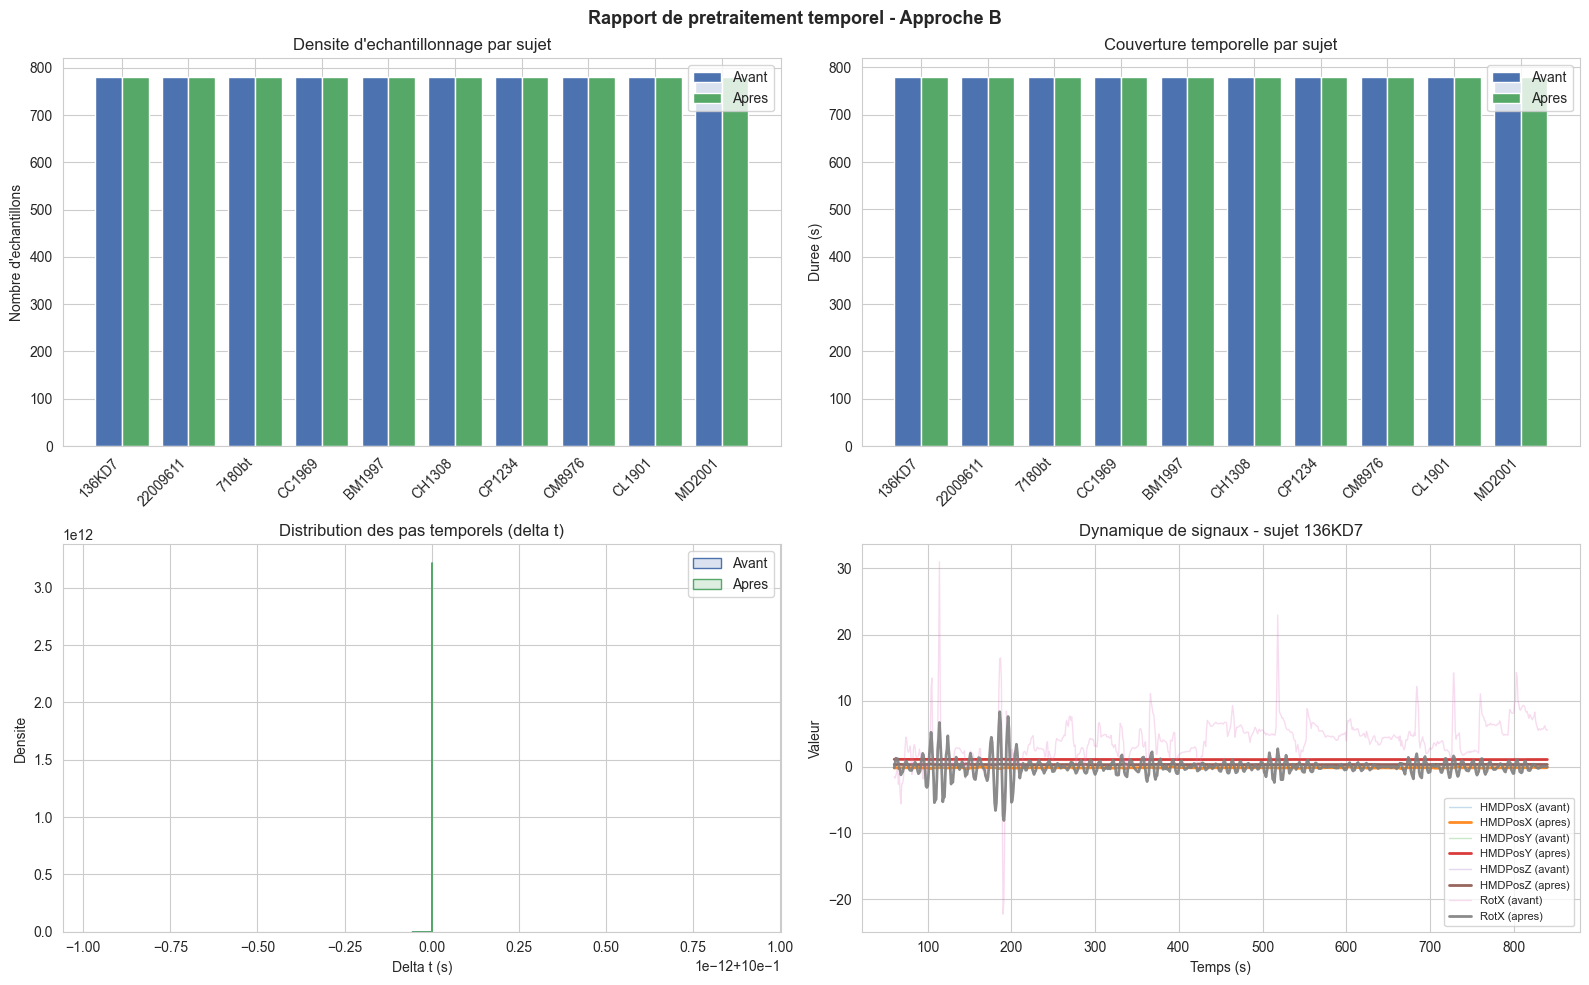

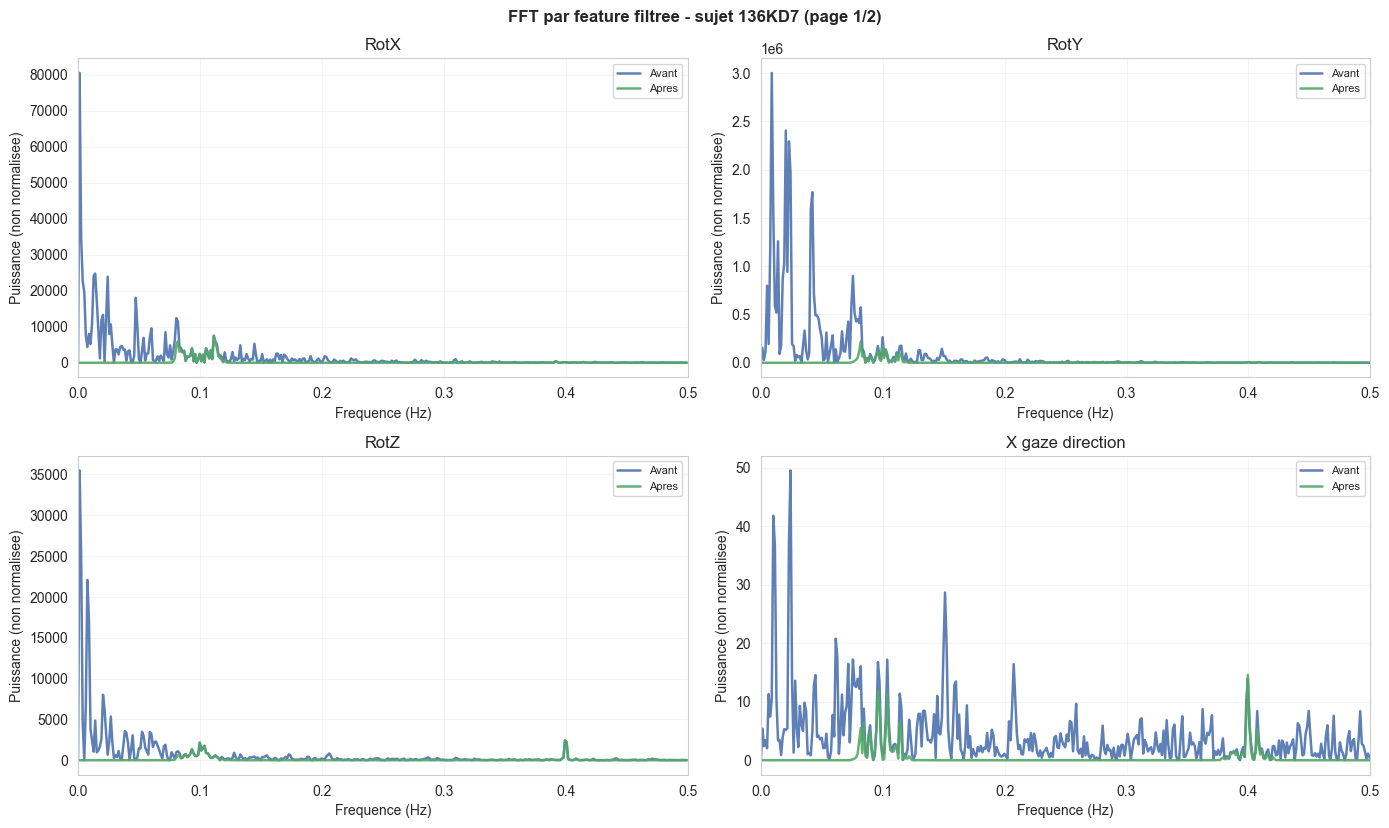

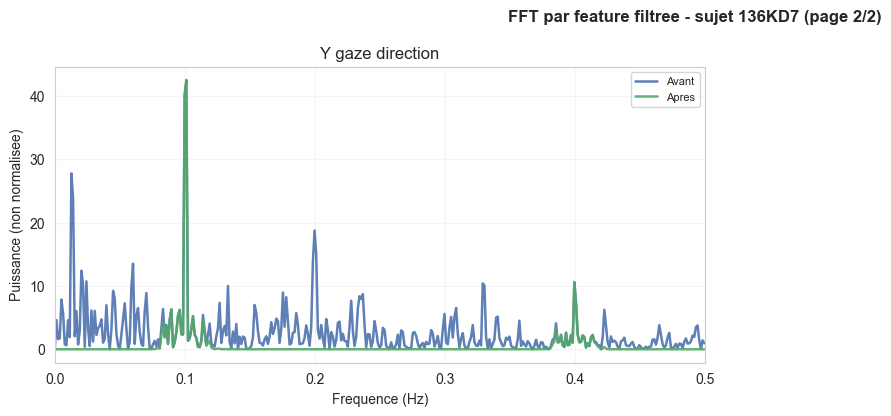

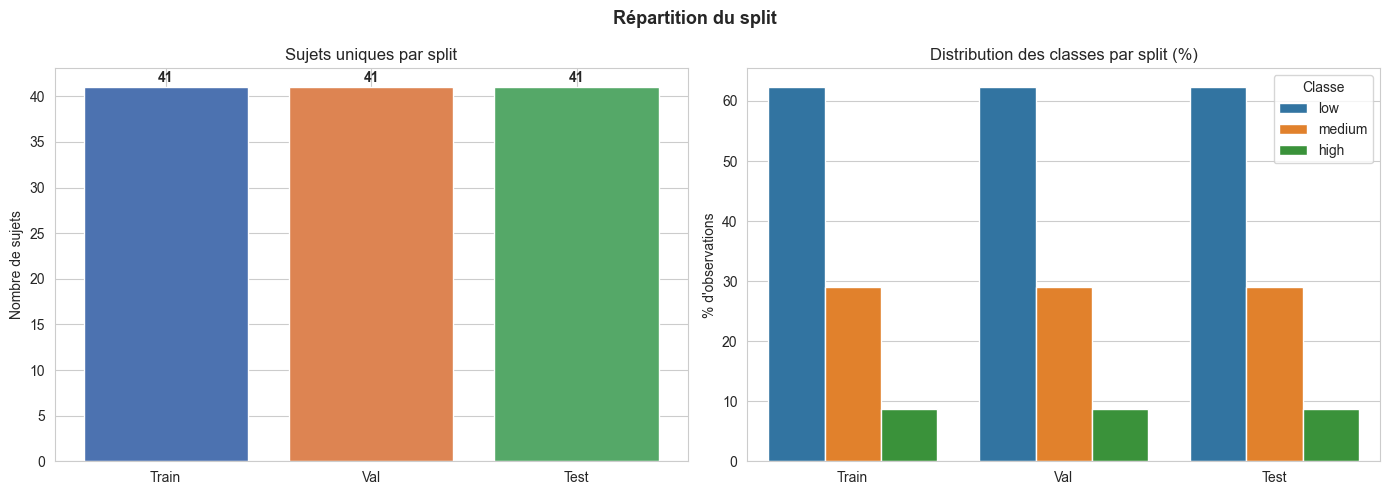

In [26]:
plot_preprocessing_report_by_approach(
    raw_df=raw_df,
    processed_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
)

plot_split_report(dataset_df, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

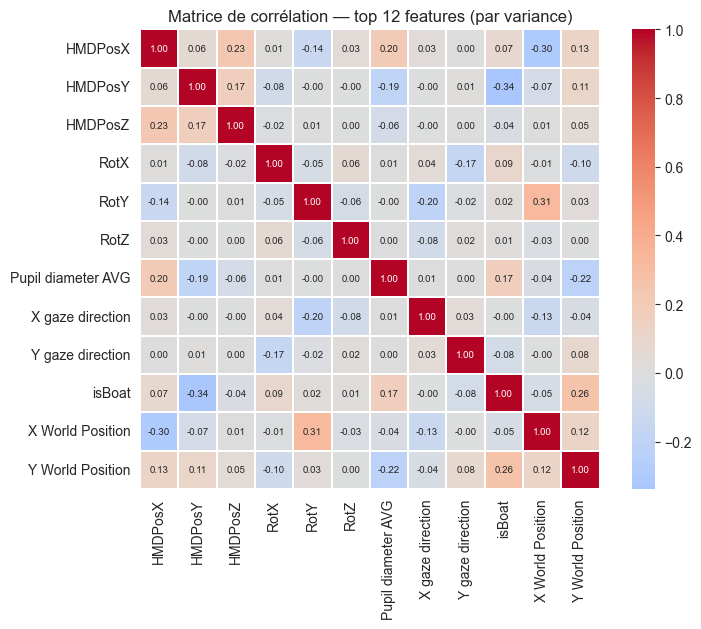

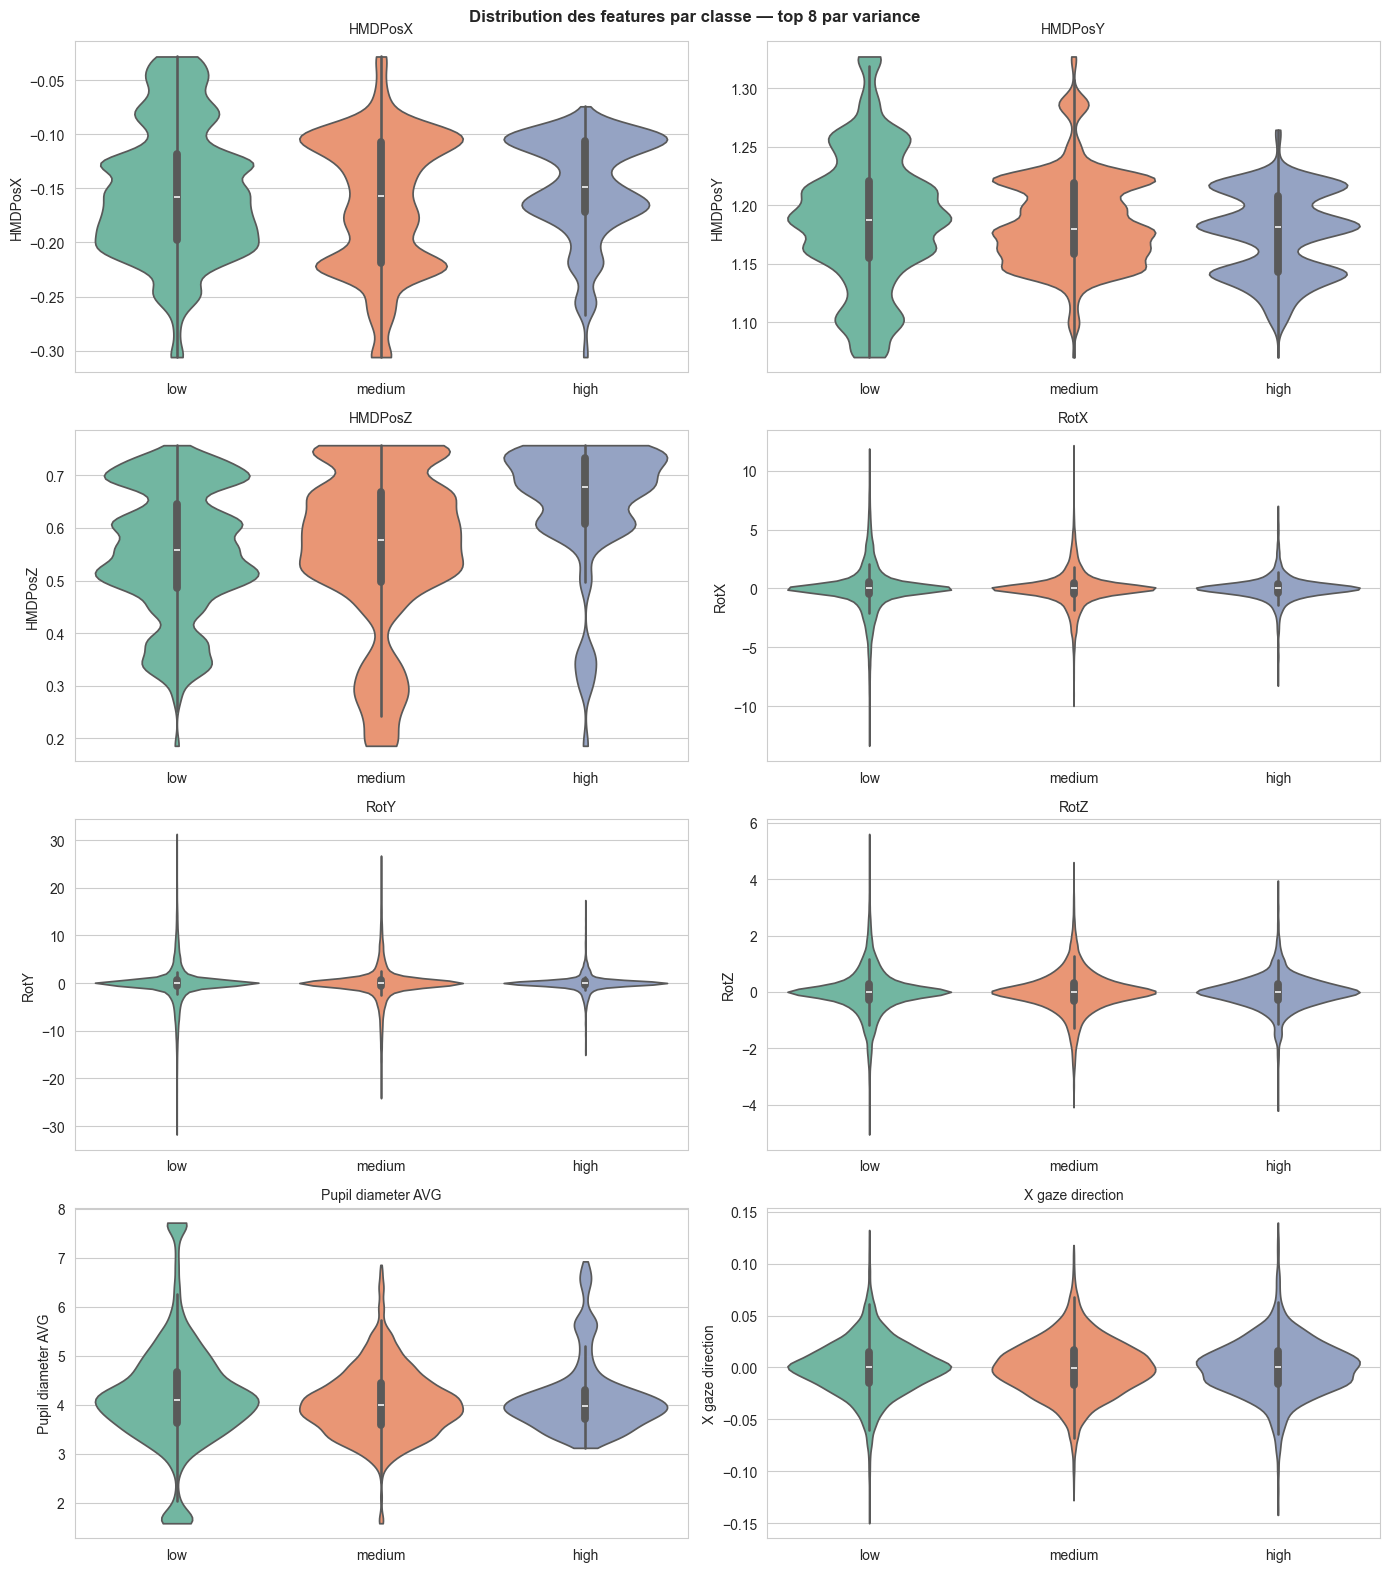

In [27]:
plot_feature_report(dataset_df, feature_cols, MODEL_PROFILE, target_profile=TARGET_PROFILE)

## 6) Optimisation hyperparametres et entrainement

In [28]:
deep_models = {"cnn_1d", "inception_time", "bilstm", "cnn_lstm"}
use_search = bool(MODEL_PROFILE.get("use_hyperparam_search", False))
sequence_length = X_train_imp.shape[1] if MODEL_PROFILE.get("model_type") in deep_models else None
n_features = 1 if MODEL_PROFILE.get("model_type") in deep_models else None

final_model, best_params, results_df = train_with_optional_hyperparameter_search(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    model_profile=MODEL_PROFILE,
    approach=PREPROCESS_PROFILE.get("approach"),
    sequence_length=sequence_length,
    n_features=n_features,
)

display(results_df.head(10))
print("Best params:", best_params)

Recherche hyperparametres desactivee: utilisation des valeurs par defaut.


,mode
0,default_parameters_used


Best params: {'sequence_length': 12, 'n_features': 1}


## 7) Evaluation, robustesse et visualisations

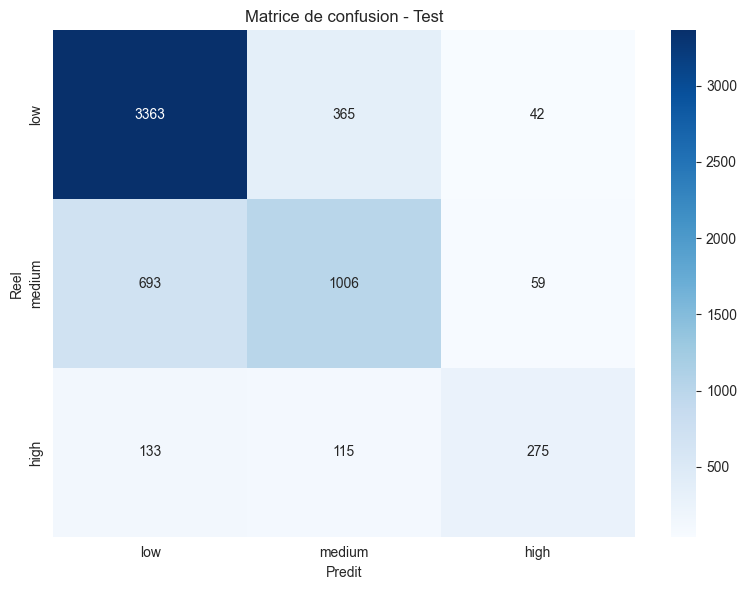

accuracy              0.767476
precision_weighted    0.760085
recall_weighted       0.767476
f1_weighted           0.759589
dtype: float64

Classification report:
              precision    recall  f1-score   support

        high       0.73      0.53      0.61       523
         low       0.80      0.89      0.85      3770
      medium       0.68      0.57      0.62      1758

    accuracy                           0.77      6051
   macro avg       0.74      0.66      0.69      6051
weighted avg       0.76      0.77      0.76      6051



,subject_id,n,accuracy,f1_weighted
0,136KD7,155.0,0.838710,0.912281
1,22009611,162.0,0.981481,0.990654
2,7180bt,169.0,0.911243,0.907723
3,933,69.0,0.666667,0.713065
4,AP1133,63.0,0.746032,0.663286
5,BD1510,86.0,0.732558,0.797500
6,BM1997,150.0,0.600000,0.599715
7,CC1969,159.0,1.000000,1.000000
8,CH1308,148.0,0.986486,0.993197
9,CL1901,151.0,0.900662,0.947735


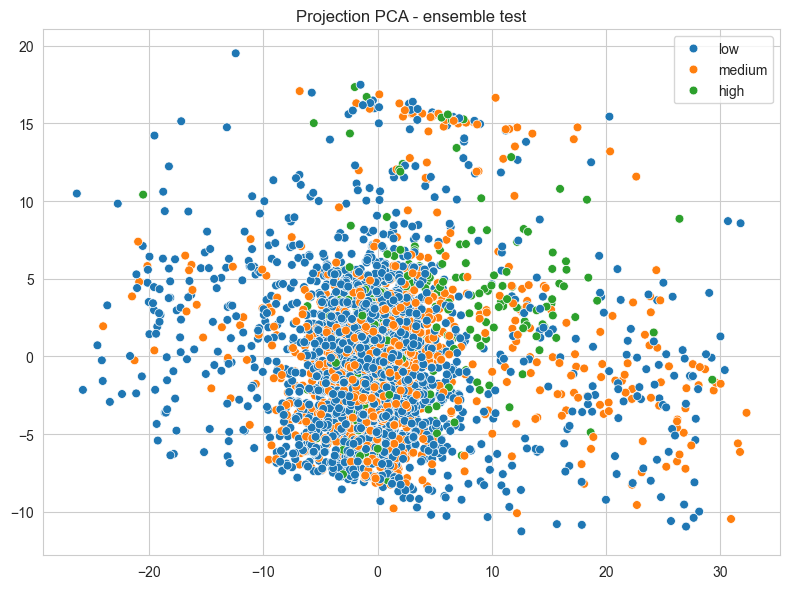

In [29]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    target_profile=TARGET_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))


imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

## 8) Fiche modele

In [35]:
export_visual_report(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    output_profile=OUTPUT_PROFILE,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    target_profile=TARGET_PROFILE,
    raw_df=raw_df,
    preprocess_profile=PREPROCESS_PROFILE,
    metrics=metrics,
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test
)

{'pages': 12,
 'report_name': 'visual_report_cnn_1d_20260521_174025',
 'pdf_path': '../data/outputs/cnn_1d_modulaire\\visual_report_cnn_1d_20260521_174025.pdf',
 'png_dir': '../data/outputs/cnn_1d_modulaire\\visual_report_cnn_1d_20260521_174025_png'}